In [1]:
import torch
import matplotlib.pyplot as plt
import ioptics as iop

In [3]:
def make_xor_regression_dataset(device: torch.device | None = None) -> tuple[torch.Tensor, torch.Tensor]:
    x_input = torch.tensor(
        [
            [0.0, 0.0],
            [0.0, 1.0],
            [1.0, 0.0],
            [1.0, 1.0],
        ],
        dtype=torch.float32,
        device=device,
    )
    y_target = torch.tensor(
        [
            [0.0],
            [1.0],
            [1.0],
            [0.0],
        ],
        dtype=torch.float32,
        device=device,
    )
    return x_input, y_target


def add_bias(x: torch.Tensor, bias_value: float = 1.0, num_bias_channels: int = 1) -> torch.Tensor:
    bias = torch.full((x.shape[0], num_bias_channels), bias_value, device=x.device, dtype=x.dtype)
    return torch.cat([x, bias], dim=1)


def build_adjoint_variation_xor_model() -> iop.OpticalNN:
    return iop.OpticalNN(
        iop.ClementsMesh(3, backward_type="adjoint variant"),
        iop.SquareActivation(),
        iop.ClementsMesh(3, output_ports=slice(0, 1), backward_type="adjoint variant"),
        iop.SquareActivation(),
        iop.AbsSquared(),
    )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
x_input, y_target = make_xor_regression_dataset(device=device)
x_input = add_bias(x_input, bias_value=1.0, num_bias_channels=1)

In [25]:
model = build_adjoint_variation_xor_model().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
criterion = torch.nn.MSELoss()

with torch.no_grad():
    initial_outputs = model(x_input).detach().cpu().squeeze(-1)

loss_history: list[float] = []
epochs = 1000

In [26]:
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(x_input)
    loss = criterion(outputs, y_target)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [100/1000], Loss: 0.2088
Epoch [200/1000], Loss: 0.0934
Epoch [300/1000], Loss: 0.0194
Epoch [400/1000], Loss: 0.0070
Epoch [500/1000], Loss: 0.0041
Epoch [600/1000], Loss: 0.0029
Epoch [700/1000], Loss: 0.0022
Epoch [800/1000], Loss: 0.0019
Epoch [900/1000], Loss: 0.0016
Epoch [1000/1000], Loss: 0.0015


In [27]:
print("\nFinal Predictions:")
with torch.no_grad():
    final_outputs = model(x_input).detach().cpu().squeeze(-1)
    y_cpu = y_target.detach().cpu().squeeze(-1)
    x_cpu = x_input.detach().cpu()
    for i in range(len(x_cpu)):
        print(f"Input: {x_cpu[i].tolist()}, Target: {y_cpu[i].item():.1f}, Pred: {final_outputs[i].item():.4f}")


Final Predictions:
Input: [0.0, 0.0, 1.0], Target: 0.0, Pred: 0.0341
Input: [0.0, 1.0, 1.0], Target: 1.0, Pred: 0.9886
Input: [1.0, 0.0, 1.0], Target: 1.0, Pred: 0.9890
Input: [1.0, 1.0, 1.0], Target: 0.0, Pred: 0.0667


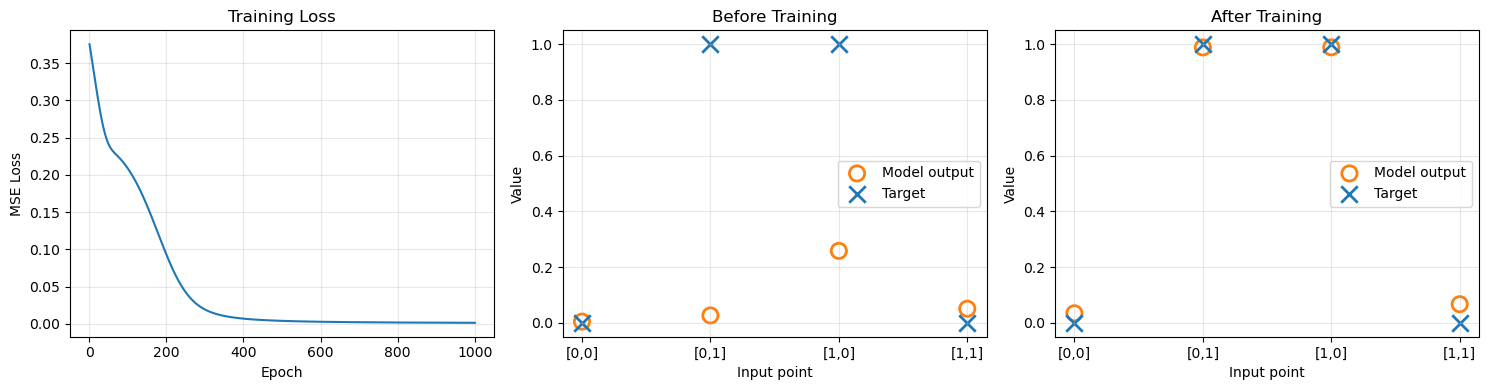

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(range(1, epochs + 1), loss_history)
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, alpha=0.3)

sample_idx = torch.arange(len(y_cpu)).numpy()
x_labels = [f"[{int(v[0])},{int(v[1])}]" for v in x_cpu.tolist()]

axes[1].scatter(sample_idx, initial_outputs.numpy(), marker="o", s=120, facecolors="none", edgecolors="C1", linewidths=2.0, label="Model output")
axes[1].scatter(sample_idx, y_cpu.numpy(), marker="x", s=140, linewidths=2.0, label="Target")
axes[1].set_title("Before Training")
axes[1].set_xlabel("Input point")
axes[1].set_ylabel("Value")
axes[1].set_xticks(sample_idx)
axes[1].set_xticklabels(x_labels)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].scatter(sample_idx, final_outputs.numpy(), marker="o", s=120, facecolors="none", edgecolors="C1", linewidths=2.0, label="Model output")
axes[2].scatter(sample_idx, y_cpu.numpy(), marker="x", s=140, linewidths=2.0, label="Target")
axes[2].set_title("After Training")
axes[2].set_xlabel("Input point")
axes[2].set_ylabel("Value")
axes[2].set_xticks(sample_idx)
axes[2].set_xticklabels(x_labels)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
# fig.savefig("adjoint_variation_xor_training_plots.png", dpi=150)
plt.show()
